# Extraindo graficos


In [ ]:
import pandas as pd

df = pd.read_csv("experiments.csv")
df.head()

,algorithm,graph_type,graph_size,n_edges,time_elapsed
0,Trad_Dijkstra,sparse,50,141,0.000269
1,Trad_Dijkstra,sparse,50,141,0.000360
2,Trad_Dijkstra,sparse,50,141,0.000229
3,Trad_Dijkstra,sparse,50,141,0.000437
4,Trad_Dijkstra,sparse,50,141,0.000293


In [ ]:
grouped = (
    df
    .groupby(['algorithm', 'graph_type', 'graph_size'])
    .agg(
        mean_time=('time_elapsed', 'mean'),
        std_time=('time_elapsed', 'std'),
        runs=('time_elapsed', 'count')
    )
    .reset_index()
)

grouped.head()

,algorithm,graph_type,graph_size,mean_time,std_time,runs
0,BMSSP,dense,50,0.000209,0.000075,50
1,BMSSP,dense,100,0.000660,0.000277,50
2,BMSSP,dense,200,0.001958,0.000117,50
3,BMSSP,dense,500,0.016058,0.004932,50
4,BMSSP,dense,1000,0.052405,0.015575,50


In [ ]:
grouped

,algorithm,graph_type,graph_size,mean_time,std_time,runs
0,BMSSP,dense,50,0.000209,0.000075,50
1,BMSSP,dense,100,0.000660,0.000277,50
2,BMSSP,dense,200,0.001958,0.000117,50
3,BMSSP,dense,500,0.016058,0.004932,50
4,BMSSP,dense,1000,0.052405,0.015575,50
5,BMSSP,sparse,50,0.000120,0.000046,50
6,BMSSP,sparse,100,0.000219,0.000023,50
7,BMSSP,sparse,200,0.000712,0.000394,50
8,BMSSP,sparse,500,0.001048,0.000088,50
9,BMSSP,sparse,1000,0.002633,0.000796,50


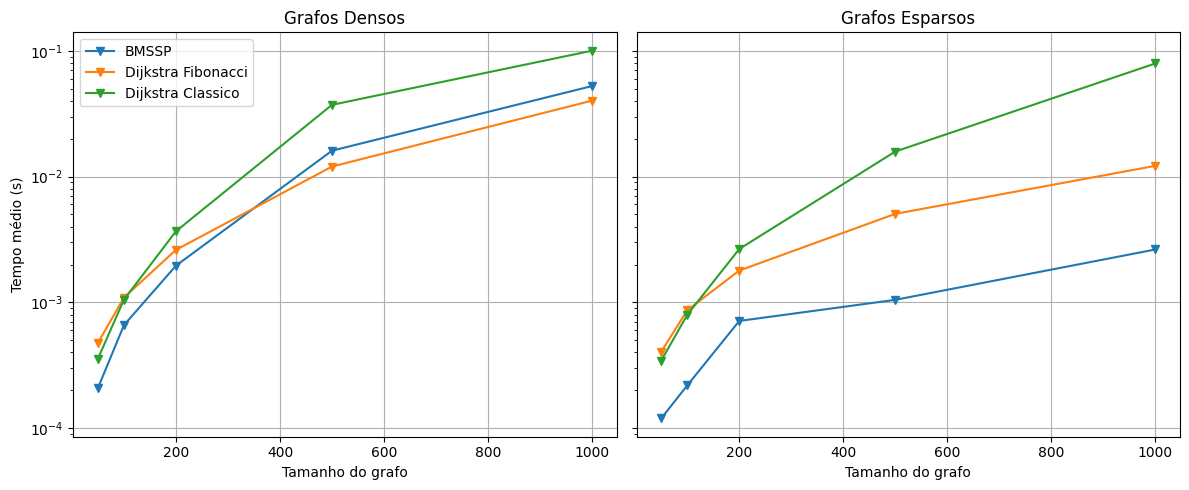

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, sharey=True, figsize=(12, 5))

# plt.xscale("log")
plt.yscale("log")
grouped = grouped.sort_values(by="graph_size")

for ax, tipo in zip(axes, ["dense", "sparse"]):
    df_tipo = grouped[grouped["graph_type"] == tipo]

    for algoritmo in df_tipo["algorithm"].unique():
        subset = df_tipo[df_tipo["algorithm"] == algoritmo]

        if algoritmo == "Trad_Dijkstra":
            algoritmo = "Dijkstra Classico"
        elif algoritmo == "Fibbo_Dijkstra":
            algoritmo = "Dijkstra Fibonacci"
        elif algoritmo == "BMSSP":
            algoritmo = "BMSSP"

        ax.errorbar(
            subset["graph_size"],
            subset["mean_time"],
            # yerr=subset["std_time"],
            marker='v',
            capsize=4,
            label=algoritmo
        )

    if tipo == "sparse":
        ax.set_title(f"Grafos {"Esparsos".capitalize()}")

    if tipo == "dense":
        ax.set_title(f"Grafos {"Densos".capitalize()}")

    ax.set_xlabel("Tamanho do grafo")
    ax.grid(True)

axes[0].set_ylabel("Tempo médio (s)")
axes[0].legend()

plt.tight_layout()
plt.show()


In [ ]:
grouped[['algorithm', "graph_size", "mean_time"]]



,algorithm,graph_size,mean_time
0,BMSSP,50,0.000209
5,BMSSP,50,0.000120
15,Fibbo_Dijkstra,50,0.000405
10,Fibbo_Dijkstra,50,0.000478
25,Trad_Dijkstra,50,0.000345
20,Trad_Dijkstra,50,0.000358
6,BMSSP,100,0.000219
11,Fibbo_Dijkstra,100,0.001093
16,Fibbo_Dijkstra,100,0.000867
21,Trad_Dijkstra,100,0.001052


# Task
Filter the DataFrame `grouped` to show only rows where 'graph_type' is 'dense' and 'algorithm' is either 'BMSSP' or 'Fibbo_Dijkstra', then display the resulting DataFrame.

## Filtrar Dados

### Subtask:
Filter the DataFrame `grouped` to include only rows where 'graph_type' is 'dense' and 'algorithm' is 'BMSSP' or 'Fibbo_Dijkstra'.


**Reasoning**:
To achieve the subtask of filtering the `grouped` DataFrame, I will apply a boolean mask to select rows where 'graph_type' is 'dense' and 'algorithm' is either 'BMSSP' or 'Fibbo_Dijkstra'.



In [ ]:
filtered_df = grouped[
    (grouped['graph_type'] == 'dense') &
    (grouped['algorithm'].isin(['BMSSP', 'Fibbo_Dijkstra']))
].drop(columns=['runs', "std_time"])

# head = ["graph_size", "graph_type", "time_execution_ratio"]
# data = []

# for row in filtered_df.iterrows():
#     print(row)
#     # data.append([row["graph_size"]])

print(filtered_df)

         algorithm graph_type  graph_size  mean_time
0            BMSSP      dense          50   0.000209
10  Fibbo_Dijkstra      dense          50   0.000478
11  Fibbo_Dijkstra      dense         100   0.001093
1            BMSSP      dense         100   0.000660
2            BMSSP      dense         200   0.001958
12  Fibbo_Dijkstra      dense         200   0.002615
3            BMSSP      dense         500   0.016058
13  Fibbo_Dijkstra      dense         500   0.012012
14  Fibbo_Dijkstra      dense        1000   0.040128
4            BMSSP      dense        1000   0.052405


## Mostrar Resultados

### Subtask:
Exibir o DataFrame filtrado para o usuário.


**Reasoning**:
The subtask is to display the filtered DataFrame. The `filtered_df` DataFrame already exists in the kernel state from the previous step. I will display the entire `filtered_df` DataFrame.



In [ ]:
filtered_df

,algorithm,graph_type,graph_size,mean_time,std_time,runs
0,BMSSP,dense,50,0.000209,0.000075,50
10,Fibbo_Dijkstra,dense,50,0.000478,0.000141,50
11,Fibbo_Dijkstra,dense,100,0.001093,0.000066,50
1,BMSSP,dense,100,0.000660,0.000277,50
2,BMSSP,dense,200,0.001958,0.000117,50
12,Fibbo_Dijkstra,dense,200,0.002615,0.000110,50
3,BMSSP,dense,500,0.016058,0.004932,50
13,Fibbo_Dijkstra,dense,500,0.012012,0.001118,50
14,Fibbo_Dijkstra,dense,1000,0.040128,0.001266,50
4,BMSSP,dense,1000,0.052405,0.015575,50


## Finalizar Tarefa

### Subtask:
Concluir a análise e apresentar os resultados filtrados.


## Summary:

### Data Analysis Key Findings
*   The `grouped` DataFrame was successfully filtered to include only rows where the 'graph\_type' is 'dense' and the 'algorithm' is either 'BMSSP' or 'Fibbo\_Dijkstra'.
*   The resulting `filtered_df` DataFrame includes columns such as 'algorithm', 'graph\_type', 'graph\_size', 'mean\_time', 'std\_time', and 'runs', confirming the successful application of the specified filter criteria.

### Insights or Next Steps
*   Further analysis should focus on comparing the 'mean\_time' and 'std\_time' metrics for 'BMSSP' and 'Fibbo\_Dijkstra' algorithms specifically on 'dense' graph types to understand their performance characteristics under these conditions.
*   Consider visualizing the performance (e.g., 'mean\_time' versus 'graph\_size') for these filtered algorithms to identify trends or significant differences.


# Task
Analisar o desempenho dos algoritmos 'BMSSP' e 'Fibbo_Dijkstra' em grafos densos, comparando seus tempos médios de execução (`mean_time`) para cada tamanho de grafo (`graph_size`) usando o DataFrame `filtered_df`.

## Analisar Desempenho por Tamanho de Grafo

### Subtask:
Analisar o DataFrame `filtered_df` para entender como o `mean_time` varia para cada algoritmo ('BMSSP' e 'Fibbo_Dijkstra') em relação ao `graph_size` em grafos densos. Isso incluirá a comparação direta dos tempos médios para cada tamanho de grafo.


**Reasoning**:
To analyze how `mean_time` varies for each algorithm concerning `graph_size`, I need to restructure `filtered_df` to easily compare the `mean_time` values for 'BMSSP' and 'Fibbo_Dijkstra' side-by-side for each `graph_size`. Pivoting the DataFrame will achieve this, placing 'algorithm' as columns and 'graph_size' as the index, with 'mean_time' as the values.



In [ ]:


comparison_df = filtered_df.pivot_table(
    index='graph_size',
    columns='algorithm',
    values='mean_time'
)

print(comparison_df)

comparison_df["ratio_BMSSP/Fibbo"] = (
    comparison_df["BMSSP"] / comparison_df["Fibbo_Dijkstra"]
)

print(comparison_df)


algorithm      BMSSP  Fibbo_Dijkstra
graph_size                          
50          0.000209        0.000478
100         0.000660        0.001093
200         0.001958        0.002615
500         0.016058        0.012012
1000        0.052405        0.040128
